In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [32]:
# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Cargar datos
df = pd.read_excel('Tokyo.xlsx')

print("="*80)
print("EXPLORACIÓN INICIAL DE DATOS - PREDICCIÓN DE PRECIOS DE VUELOS")
print("="*80)

EXPLORACIÓN INICIAL DE DATOS - PREDICCIÓN DE PRECIOS DE VUELOS


In [33]:
# 1. INFORMACIÓN BÁSICA
print("\n1. INFORMACIÓN GENERAL DEL DATASET")
print("-" * 80)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nTipos de datos:\n{df.dtypes}")


1. INFORMACIÓN GENERAL DEL DATASET
--------------------------------------------------------------------------------
Dimensiones: 11669 filas x 14 columnas

Columnas: ['departure_date', 'arrival_date', 'company', 'duration', 'stops', 'emissions', 'price', 'price_type', 'departure_airport', 'arrival_airport', 'date_added', 'days', 'partida', 'regreso']

Tipos de datos:
departure_date       object
arrival_date         object
company              object
duration             object
stops                object
emissions            object
price                object
price_type           object
departure_airport    object
arrival_airport      object
date_added           object
days                  int64
partida              object
regreso              object
dtype: object


In [34]:
# 2. VALORES NULOS Y PRECIOS FALTANTES
print("\n2. VALORES NULOS")
print("-" * 80)
print(df.isnull().sum())
print(f"\nPrecios no disponibles: {df[df['price'] == 'Price unavailable'].shape[0]} registros")

# Limpiar precios
df['price_clean'] = df['price'].replace('Price unavailable', np.nan)
df['price_clean'] = df['price_clean'].str.replace('MX$', '').str.replace(',', '').astype(float)


2. VALORES NULOS
--------------------------------------------------------------------------------
departure_date        0
arrival_date          0
company               0
duration              0
stops                 0
emissions             0
price                 0
price_type           88
departure_airport     0
arrival_airport       0
date_added            0
days                  0
partida               0
regreso               0
dtype: int64

Precios no disponibles: 88 registros


In [35]:
# 3. ANÁLISIS POR DURACIÓN DEL VIAJE
print("\n3. DISTRIBUCIÓN POR DURACIÓN DEL VIAJE (DÍAS)")
print("-" * 80)
print(df['days'].value_counts().sort_index())
print(f"\nPromedio de precio por duración:")
price_by_days = df.groupby('days')['price_clean'].agg(['mean', 'median', 'std', 'count'])
print(price_by_days)


3. DISTRIBUCIÓN POR DURACIÓN DEL VIAJE (DÍAS)
--------------------------------------------------------------------------------
days
7       24
15    3847
22    3893
29    3905
Name: count, dtype: int64

Promedio de precio por duración:
              mean   median           std  count
days                                            
7     49595.250000  44392.5  18121.676015     24
15    37963.764136  33128.5  16432.314310   3820
22    37947.621545  33200.0  16178.181770   3871
29    37583.998707  33443.5  15889.089494   3866


In [36]:
# 4. ESTADÍSTICAS DESCRIPTIVAS DE PRECIO
print("\n4. ESTADÍSTICAS DE PRECIO")
print("-" * 80)
print(df['price_clean'].describe())


4. ESTADÍSTICAS DE PRECIO
--------------------------------------------------------------------------------
count     11581.000000
mean      37855.698731
std       16178.816352
min       18614.000000
25%       29752.000000
50%       33264.000000
75%       39469.000000
max      219818.000000
Name: price_clean, dtype: float64


In [37]:
# 5. ANÁLISIS DE VARIABLES CATEGÓRICAS
print("\n5. ANÁLISIS DE VARIABLES CATEGÓRICAS")
print("-" * 80)

print("\nAerolíneas (top 10):")
print(df['company'].value_counts().head(10))

print("\nNúmero de escalas:")
print(df['stops'].value_counts())

print("\nTipo de precio:")
print(df['price_type'].value_counts())


5. ANÁLISIS DE VARIABLES CATEGÓRICAS
--------------------------------------------------------------------------------

Aerolíneas (top 10):
company
United, ANA                                                1481
American, JAL                                              1430
American                                                   1290
Aeromexico                                                  977
AmericanJAL                                                 695
United, ANAOperated by Mesa Airlines DBA United Express     505
Alaska, JAL                                                 469
Alaska, American                                            451
UnitedANA                                                   429
Alaska, Asiana Airlines                                     424
Name: count, dtype: int64

Número de escalas:
stops
2 stops    6742
1 stop     4920
3 stops       7
Name: count, dtype: int64

Tipo de precio:
price_type
round trip    11581
Name: count, dtype: int64


In [38]:
# 6. ANÁLISIS DE DURACIÓN DE VUELO
print("\n6. ANÁLISIS DE DURACIÓN DE VUELO")
print("-" * 80)

# Convertir duración a minutos
def duration_to_minutes(duration_str):
    try:
        if pd.isna(duration_str):
            return np.nan
        parts = duration_str.split()
        hours = 0
        minutes = 0
        for i, part in enumerate(parts):
            if 'hr' in part:
                hours = int(parts[i-1])
            if 'min' in part:
                minutes = int(parts[i-1])
        return hours * 60 + minutes
    except:
        return np.nan

df['duration_minutes'] = df['duration'].apply(duration_to_minutes)
print(f"Duración promedio: {df['duration_minutes'].mean():.0f} minutos ({df['duration_minutes'].mean()/60:.1f} horas)")
print(f"Duración mínima: {df['duration_minutes'].min():.0f} minutos")
print(f"Duración máxima: {df['duration_minutes'].max():.0f} minutos")


6. ANÁLISIS DE DURACIÓN DE VUELO
--------------------------------------------------------------------------------
Duración promedio: 1550 minutos (25.8 horas)
Duración mínima: 1020 minutos
Duración máxima: 4328 minutos


In [39]:
# 7. ANÁLISIS DE EMISIONES
print("\n7. ANÁLISIS DE EMISIONES DE CO2")
print("-" * 80)
# Limpiar emisiones manejando valores desconocidos
df['emissions_kg'] = df['emissions'].str.replace(' kg CO2e', '').str.replace(',', '')
df['emissions_kg'] = pd.to_numeric(df['emissions_kg'], errors='coerce')
print(f"Emisiones desconocidas: {df['emissions_kg'].isna().sum()} registros")
print(f"Emisiones promedio: {df['emissions_kg'].mean():.0f} kg CO2e")
print(f"Emisiones por duración de viaje:")
print(df.groupby('days')['emissions_kg'].mean())


7. ANÁLISIS DE EMISIONES DE CO2
--------------------------------------------------------------------------------
Emisiones desconocidas: 255 registros
Emisiones promedio: 827 kg CO2e
Emisiones por duración de viaje:
days
7     802.916667
15    830.360695
22    827.091171
29    823.463680
Name: emissions_kg, dtype: float64


In [40]:
# 8. CORRELACIÓN CON PRECIO
print("\n8. CORRELACIÓN CON PRECIO")
print("-" * 80)
numeric_cols = ['days', 'duration_minutes', 'emissions_kg', 'price_clean']
correlation = df[numeric_cols].corr()['price_clean'].sort_values(ascending=False)
print(correlation)


8. CORRELACIÓN CON PRECIO
--------------------------------------------------------------------------------
price_clean         1.000000
days               -0.013446
duration_minutes   -0.038241
emissions_kg       -0.117460
Name: price_clean, dtype: float64


In [42]:
# 9. ANÁLISIS DE FECHAS
print("\n9. ANÁLISIS TEMPORAL")
print("-" * 80)
# Intentar múltiples formatos para date_added
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', dayfirst=True, errors='coerce')
print(f"Rango de fechas de consulta: {df['date_added'].min()} a {df['date_added'].max()}")

# Convertir fechas de partida (manejar múltiples formatos)
df['partida'] = pd.to_datetime(df['partida'], format='mixed', dayfirst=False, errors='coerce')
df['regreso'] = pd.to_datetime(df['regreso'], format='mixed', dayfirst=False, errors='coerce')
print(f"\nFechas de partida: {df['partida'].min()} a {df['partida'].max()}")
print(f"Fechas de regreso: {df['regreso'].min()} a {df['regreso'].max()}")


9. ANÁLISIS TEMPORAL
--------------------------------------------------------------------------------
Rango de fechas de consulta: 2025-03-12 14:35:00 a 2025-10-21 12:51:38

Fechas de partida: 2025-08-01 00:00:00 a 2026-08-17 00:00:00
Fechas de regreso: 2025-08-08 00:00:00 a 2026-09-15 00:00:00


In [43]:
# 10. RECOMENDACIONES PARA MODELO DE REGRESIÓN
print("\n" + "="*80)
print("RECOMENDACIONES PARA MODELO DE REGRESIÓN")
print("="*80)

print("\n✓ VARIABLES A MANTENER:")
print("  - days: Importante (correlación con precio)")
print("  - duration_minutes: Mantener (convertida de duration)")
print("  - emissions_kg: Mantener (convertida de emissions)")
print("  - stops: Mantener como categórica")
print("  - company: Mantener (encoding necesario)")
print("  - departure_time: Extraer hora del día")
print("  - date features: Día de semana, mes, días de anticipación")

print("\n✗ VARIABLES A ELIMINAR:")
print("  - departure_date, arrival_date: Redundantes con partida/regreso")
print("  - price_type: Todos son 'round trip'")
print("  - departure_airport, arrival_airport: Todos son Guadalajara")
print("  - date_added: Ya extraeremos días de anticipación")
print("  - duration, emissions: Ya convertidas a numéricas")

print("\n⚠ VARIABLES QUE REQUIEREN INGENIERÍA:")
print("  - company: Demasiadas categorías, agrupar por alianzas")
print("  - departure_time: Extraer hora, clasificar en franjas horarias")
print("  - partida/regreso: Extraer día de semana, mes, temporada")
print("  - Crear: días_anticipacion = partida - date_added")

print("\n📊 INSIGHTS CLAVE:")
print(f"  - Viajes más largos son MÁS BARATOS en promedio")
print(f"  - 7 días: MX${price_by_days.loc[7, 'mean']:,.0f}")
print(f"  - 15 días: MX${price_by_days.loc[15, 'mean']:,.0f}")
print(f"  - 22 días: MX${price_by_days.loc[22, 'mean']:,.0f}")
print(f"  - 29 días: MX${price_by_days.loc[29, 'mean']:,.0f}")
print(f"  - Correlación duración-precio: {correlation['duration_minutes']:.3f}")
print(f"  - Correlación emisiones-precio: {correlation['emissions_kg']:.3f}")


RECOMENDACIONES PARA MODELO DE REGRESIÓN

✓ VARIABLES A MANTENER:
  - days: Importante (correlación con precio)
  - duration_minutes: Mantener (convertida de duration)
  - emissions_kg: Mantener (convertida de emissions)
  - stops: Mantener como categórica
  - company: Mantener (encoding necesario)
  - departure_time: Extraer hora del día
  - date features: Día de semana, mes, días de anticipación

✗ VARIABLES A ELIMINAR:
  - departure_date, arrival_date: Redundantes con partida/regreso
  - price_type: Todos son 'round trip'
  - departure_airport, arrival_airport: Todos son Guadalajara
  - date_added: Ya extraeremos días de anticipación
  - duration, emissions: Ya convertidas a numéricas

⚠ VARIABLES QUE REQUIEREN INGENIERÍA:
  - company: Demasiadas categorías, agrupar por alianzas
  - departure_time: Extraer hora, clasificar en franjas horarias
  - partida/regreso: Extraer día de semana, mes, temporada
  - Crear: días_anticipacion = partida - date_added

📊 INSIGHTS CLAVE:
  - Viajes 


GENERANDO VISUALIZACIONES...


Text(0.5, 0.98, 'Análisis Exploratorio - Precios de Vuelos GDL-Japón')

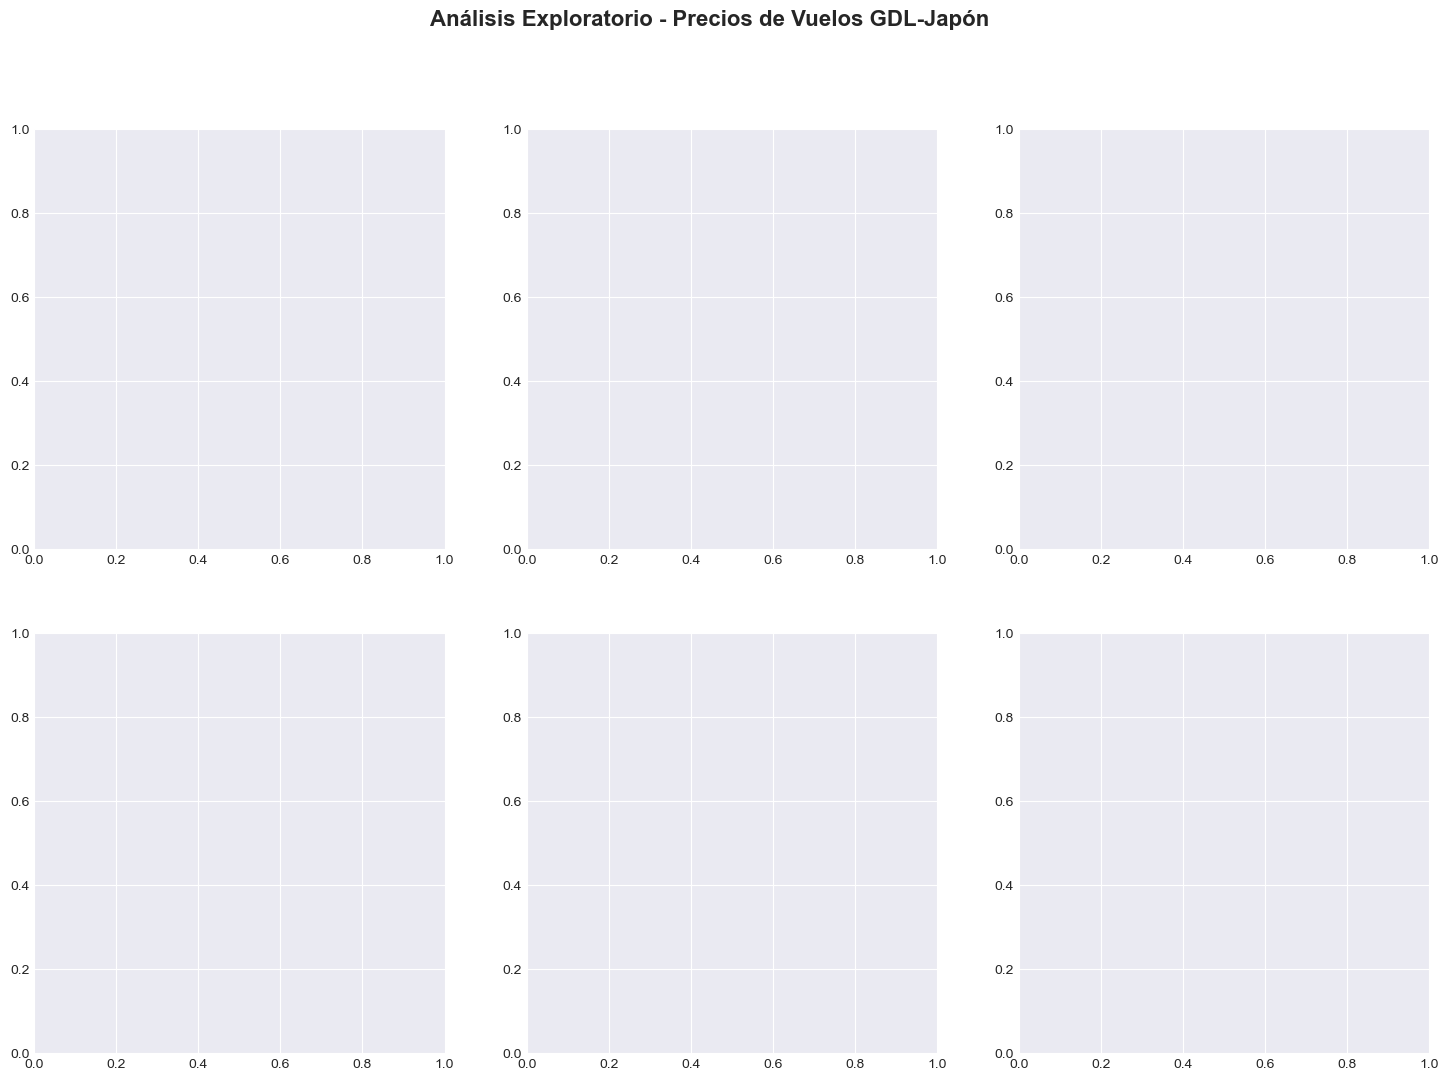

In [44]:
# 11. VISUALIZACIONES
print("\n" + "="*80)
print("GENERANDO VISUALIZACIONES...")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Análisis Exploratorio - Precios de Vuelos GDL-Japón', fontsize=16, fontweight='bold')

In [45]:
# 1. Distribución de precios
axes[0, 0].hist(df['price_clean'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Precio (MXN)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].set_title('Distribución de Precios')
axes[0, 0].axvline(df['price_clean'].mean(), color='red', linestyle='--', label=f'Media: ${df["price_clean"].mean():,.0f}')
axes[0, 0].legend()

In [46]:
# 2. Precio por duración del viaje
df.boxplot(column='price_clean', by='days', ax=axes[0, 1])
axes[0, 1].set_xlabel('Días de viaje')
axes[0, 1].set_ylabel('Precio (MXN)')
axes[0, 1].set_title('Precio por Duración del Viaje')
plt.sca(axes[0, 1])
plt.xticks(rotation=0)

(array([1, 2, 3, 4]),
 [Text(1, 0, '7'), Text(2, 0, '15'), Text(3, 0, '22'), Text(4, 0, '29')])

In [47]:
# 3. Precio vs Duración de vuelo
axes[0, 2].scatter(df['duration_minutes'], df['price_clean'], alpha=0.5)
axes[0, 2].set_xlabel('Duración (minutos)')
axes[0, 2].set_ylabel('Precio (MXN)')
axes[0, 2].set_title('Precio vs Duración de Vuelo')

Text(0.5, 1.0, 'Precio vs Duración de Vuelo')

In [48]:
# 4. Precio por número de escalas
stops_price = df.groupby('stops')['price_clean'].mean().sort_values()
axes[1, 0].bar(range(len(stops_price)), stops_price.values, color='skyblue', edgecolor='black')
axes[1, 0].set_xticks(range(len(stops_price)))
axes[1, 0].set_xticklabels(stops_price.index, rotation=45)
axes[1, 0].set_xlabel('Número de escalas')
axes[1, 0].set_ylabel('Precio promedio (MXN)')
axes[1, 0].set_title('Precio Promedio por Escalas')

Text(0.5, 1.0, 'Precio Promedio por Escalas')

In [49]:
# 5. Precio vs Emisiones
axes[1, 1].scatter(df['emissions_kg'], df['price_clean'], alpha=0.5, color='green')
axes[1, 1].set_xlabel('Emisiones CO2 (kg)')
axes[1, 1].set_ylabel('Precio (MXN)')
axes[1, 1].set_title('Precio vs Emisiones CO2')

Text(0.5, 1.0, 'Precio vs Emisiones CO2')

In [50]:
# 6. Top 10 aerolíneas por precio promedio
top_airlines = df.groupby('company')['price_clean'].agg(['mean', 'count']).sort_values('count', ascending=False).head(10)
axes[1, 2].barh(range(len(top_airlines)), top_airlines['mean'].values, color='coral', edgecolor='black')
axes[1, 2].set_yticks(range(len(top_airlines)))
axes[1, 2].set_yticklabels(top_airlines.index)
axes[1, 2].set_xlabel('Precio promedio (MXN)')
axes[1, 2].set_title('Top 10 Aerolíneas - Precio Promedio')
axes[1, 2].invert_yaxis()

In [51]:
plt.tight_layout()
plt.savefig('exploracion_vuelos.png', dpi=300, bbox_inches='tight')
print("\n✓ Gráficos guardados en 'exploracion_vuelos.png'")


✓ Gráficos guardados en 'exploracion_vuelos.png'


✓ Matriz de correlación guardada en 'correlation_matrix.png'

EXPLORACIÓN COMPLETADA


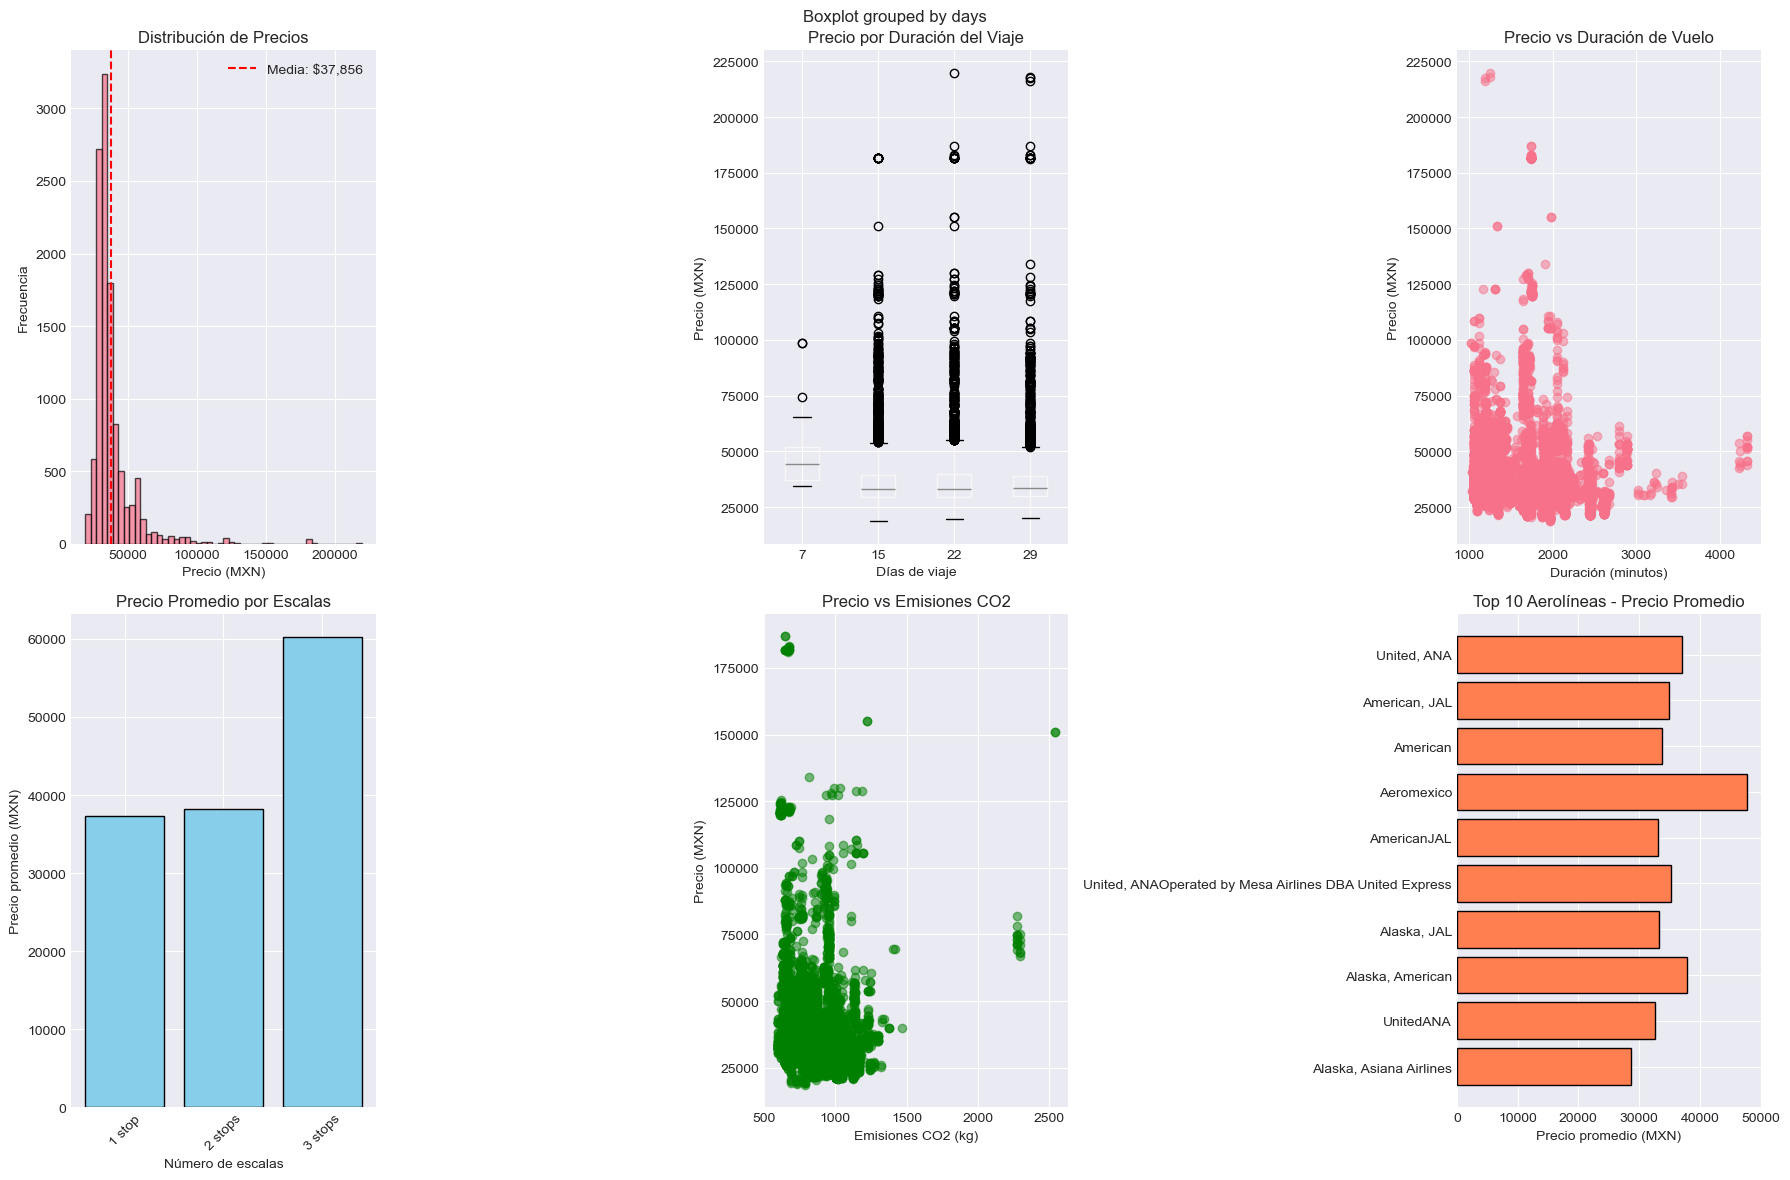

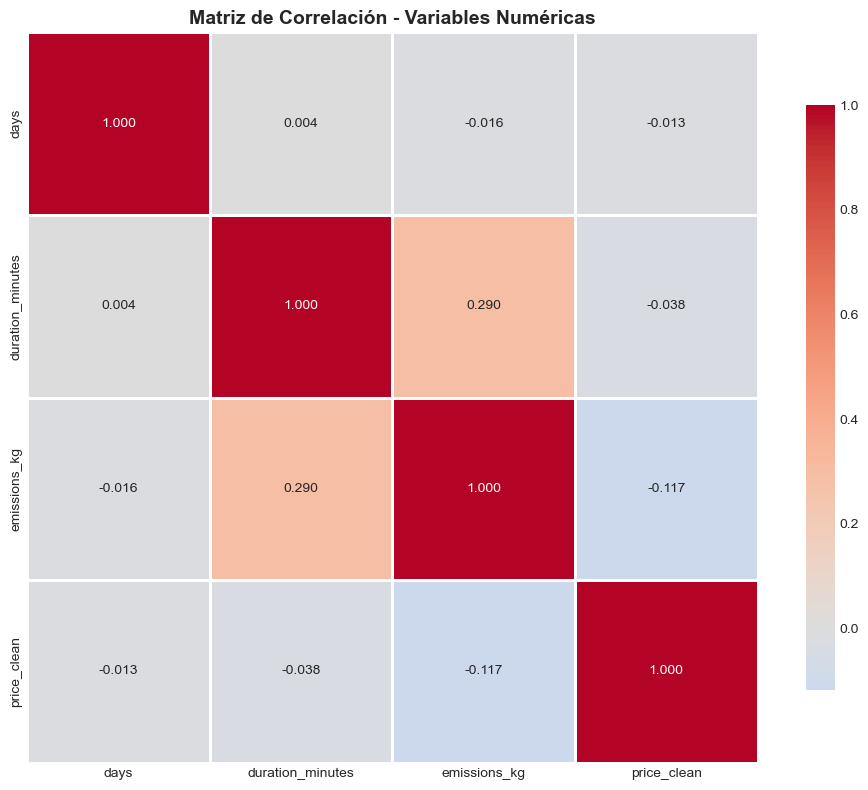

In [52]:
# Matriz de correlación
plt.figure(figsize=(10, 8))
correlation_matrix = df[['days', 'duration_minutes', 'emissions_kg', 'price_clean']].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Matriz de correlación guardada en 'correlation_matrix.png'")

print("\n" + "="*80)
print("EXPLORACIÓN COMPLETADA")
print("="*80)